In [9]:
import mne

file_path = "../../data/intrmd_data/epochs/stim/g_stim/sub-021_stim_epo.fif"

# Try loading as epochs
epochs = mne.read_epochs(file_path, preload=False)
epochs

Reading /Users/pramit/Documents/projects/neuro_astic/scripts/foo/../../data/intrmd_data/epochs/stim/g_stim/sub-021_stim_epo.fif ...
    Found the data of interest:
        t =   -4000.00 ...   11000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
169 matching events found
No baseline correction applied
0 projection items activated


<EpochsFIF | 169 events (all good), -4 – 11 s (baseline -4 – 0 s), ~100 kB, data not loaded, with metadata,
 '2': 169>

In [2]:
import numpy as np

data = epochs.get_data()

# mean over baseline window
baseline_mean = data[:, :, : int(4 * 512)].mean()

print(baseline_mean)

Loading data for 169 events and 7681 original time points ...
6.422274629733095e-10


In [3]:
print(epochs.get_data().shape)

Loading data for 169 events and 7681 original time points ...
(169, 70, 7681)


Using matplotlib as 2D backend.


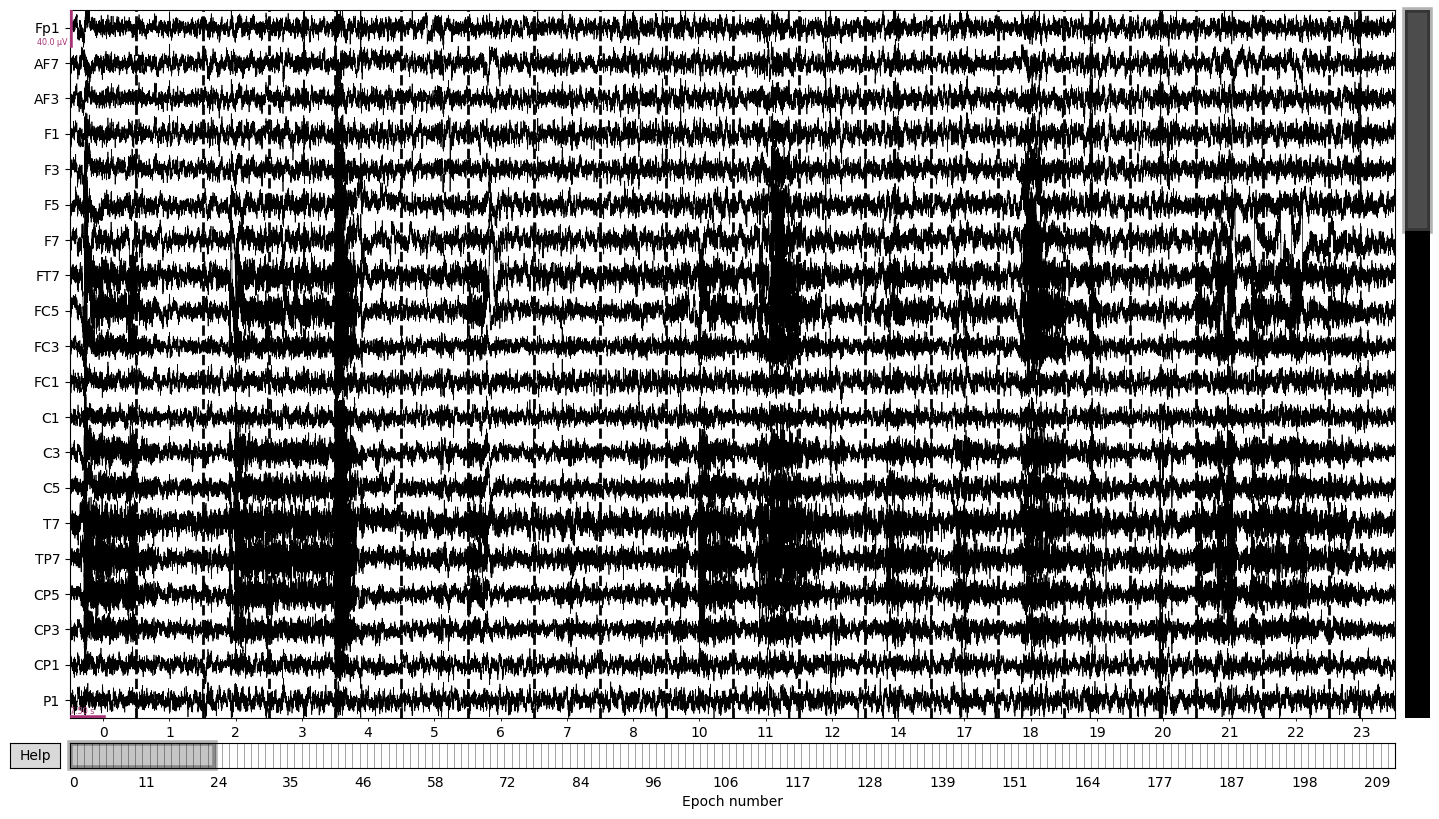

In [3]:
epochs.plot();

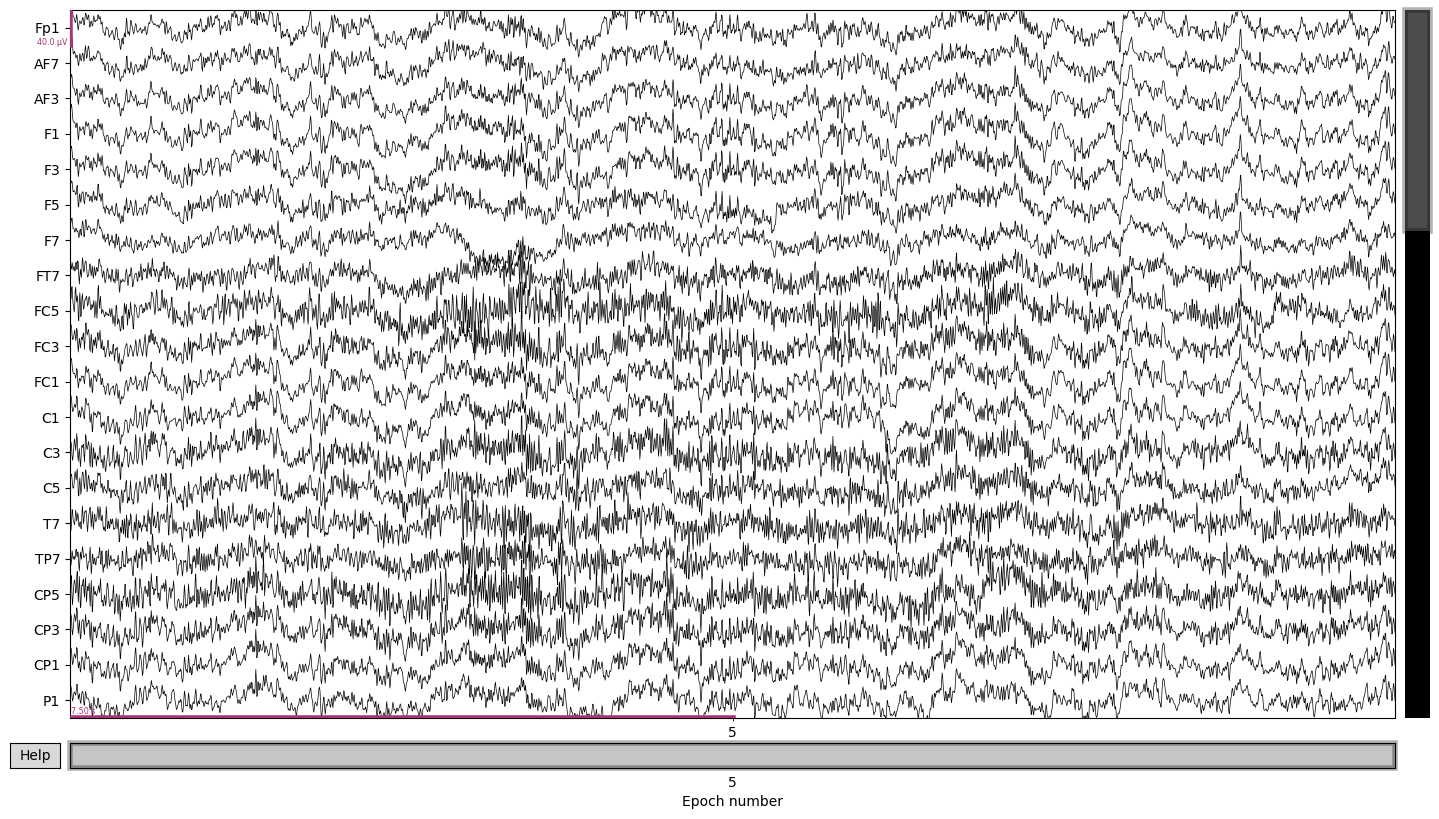

In [4]:
epochs[0].plot();

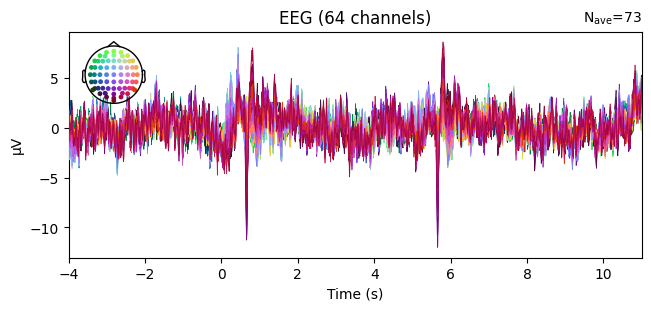

In [5]:
evoked = epochs.average()
evoked.plot();

In [4]:
print("Total epochs:", len(epochs))

sfreq = epochs.info["sfreq"]

# event sample indices
samples = epochs.events[:, 0]

# convert to seconds
times = samples / sfreq

print(times[:10])

Total epochs: 169
[608.53710938 649.16796875 688.02734375 722.85351562 760.45703125
 800.1640625  833.79492188 905.03125    934.5859375  973.58984375]


In [10]:
epochs = mne.read_epochs(
    "../../data/intrmd_data/epochs/stim/whole_stim/sub-021_allstim_epo.fif",
    preload=False,
)
epochs.get_data().shape

Reading /Users/pramit/Documents/projects/neuro_astic/scripts/foo/../../data/intrmd_data/epochs/stim/whole_stim/sub-021_allstim_epo.fif ...
    Found the data of interest:
        t =   -4000.00 ...   11000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
210 matching events found
No baseline correction applied
0 projection items activated
Loading data for 210 events and 7681 original time points ...


(210, 70, 7681)

In [9]:
print(len(epochs))  # should be 210
print(epochs.metadata.head())  # should start from 0

print(
    len(
        mne.read_epochs(
            "../../data/intrmd_data/epochs/stim/whole_stim/sub-021_allstim_epo.fif"
        )
    )
)  # should be 210
print(
    len(
        mne.read_epochs(
            "../../data/intrmd_data/epochs/stim/b_stim/sub-021_badstim_epo.fif"
        )
    )
)  # ~180–200

210
   trial_index
2            0
3            1
4            2
5            3
6            4
Reading /Users/pramit/Documents/projects/neuro_astic/scripts/foo/../../data/intrmd_data/epochs/stim/whole_stim/sub-021_allstim_epo.fif ...
    Found the data of interest:
        t =   -4000.00 ...   11000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
210 matching events found
No baseline correction applied
0 projection items activated
210
Reading /Users/pramit/Documents/projects/neuro_astic/scripts/foo/../../data/intrmd_data/epochs/stim/b_stim/sub-021_badstim_epo.fif ...
    Found the data of interest:
        t =   -4000.00 ...   11000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
41 matching events found
No baseline correction applied
0 projection items activated
41


In [2]:
import pyarrow.parquet as pq

table = pq.read_table(
    "../../data/intrmd_data/labeled/sub-021_whole.parquet",
    thrift_string_size_limit=2**31 - 1,
    thrift_container_size_limit=2**31 - 1,
)

df = table.to_pandas()


In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,trial_index,PoemType,Block,AA,Imagery,Moved,Originality,Creativity,PoemType_enc,Block_enc
0,2.856500e-05,0.000028,0.000026,0.000023,2.035930e-05,0.000018,0.000017,0.000016,1.603634e-05,0.000017,...,0,S,Block-5,4,4,6,5,4,2,4
1,4.577732e-07,0.000001,0.000002,0.000001,3.206834e-07,-0.000001,-0.000003,-0.000004,-5.847019e-06,-0.000007,...,1,C,None,2,3,3,2,4,0,7
2,2.790085e-06,0.000002,0.000002,0.000003,3.967193e-06,0.000004,0.000004,0.000002,-3.906774e-07,-0.000003,...,2,C,None,4,4,3,4,3,0,7
3,-1.707383e-05,-0.000018,-0.000018,-0.000017,-1.678269e-05,-0.000016,-0.000016,-0.000017,-1.736939e-05,-0.000018,...,3,H,None,5,6,4,5,5,1,7
4,5.013728e-05,0.000052,0.000054,0.000054,5.355056e-05,0.000052,0.000050,0.000048,4.692169e-05,0.000046,...,4,S,None,5,6,6,5,6,2,7


In [5]:
print(df.iloc[:, :10].describe())
import os

size_mb = os.path.getsize("../../data/intrmd_data/labeled/sub-021_whole.parquet") / (
    1024 * 1024
)
print(f"Size: {size_mb:.2f} MB")

                0           1           2           3             4  \
count  210.000000  210.000000  210.000000  210.000000  2.100000e+02   
mean     0.000002    0.000001    0.000001    0.000001  9.691877e-07   
std      0.000014    0.000014    0.000014    0.000014  1.468772e-05   
min     -0.000051   -0.000049   -0.000050   -0.000053 -5.898156e-05   
25%     -0.000007   -0.000007   -0.000006   -0.000007 -7.243336e-06   
50%      0.000003    0.000003    0.000002    0.000002  1.623564e-06   
75%      0.000011    0.000010    0.000011    0.000011  1.099950e-05   
max      0.000050    0.000052    0.000054    0.000054  5.355056e-05   

                  5           6           7           8           9  
count  2.100000e+02  210.000000  210.000000  210.000000  210.000000  
mean   9.517939e-07    0.000001    0.000001    0.000001    0.000002  
std    1.474400e-05    0.000015    0.000015    0.000015    0.000015  
min   -6.168829e-05   -0.000064   -0.000065   -0.000064   -0.000062  
25%   -7.1

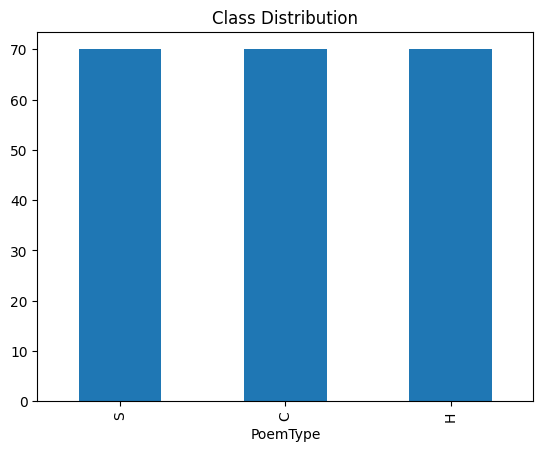

In [6]:
import matplotlib.pyplot as plt

df["PoemType"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

In [1]:
import pandas as pd

features_df = pd.read_parquet("../../data/features/sub-021_bpfeatures.parquet")

features_df.head(10)

,early_delta_Fp1,early_theta_Fp1,early_alpha_Fp1,early_beta_Fp1,early_gamma_Fp1,early_delta_AF7,early_theta_AF7,early_alpha_AF7,early_beta_AF7,early_gamma_AF7,...,late_beta_O2,late_gamma_O2,trial_index,PoemType,Block,AA,Imagery,Moved,Originality,Creativity
0,-0.221025,-0.007455,-0.000855,0.001507,-0.000620,-0.124852,-0.007347,-0.005230,0.001291,-0.000774,...,-0.001009,-0.002723,0,S,Block-5,4,4,6,5,4
1,0.076247,0.001879,0.000560,0.000405,-0.000464,0.019517,0.008391,0.002342,-0.000508,-0.000172,...,0.003369,0.000135,1,C,None,2,3,3,2,4
2,-0.100803,-0.018938,-0.009759,-0.003010,-0.000348,-0.134869,-0.019474,-0.011622,-0.003140,-0.000036,...,-0.000844,-0.001983,2,C,None,4,4,3,4,3
3,-0.004366,-0.001675,0.006613,0.004776,0.000577,-0.001505,0.001707,0.010055,0.003703,0.001076,...,-0.007296,-0.000475,3,H,None,5,6,4,5,5
4,-1.258609,-0.002735,-0.026222,-0.000469,-0.001389,-0.907842,-0.000941,-0.016779,0.000939,-0.001308,...,-0.000175,-0.001994,4,S,None,5,6,6,5,6
5,0.023407,0.000448,-0.008461,0.000367,-0.000071,0.044141,-0.002640,-0.007511,0.000188,0.000194,...,0.007440,-0.000479,5,H,None,5,4,4,5,4
6,0.044074,0.000706,-0.035293,-0.000017,0.001098,-0.012998,-0.008220,-0.025024,0.000698,0.000707,...,0.010971,-0.000098,6,H,None,5,5,4,5,5
7,-0.492624,-0.019786,-0.010133,-0.000716,0.000149,-0.655798,-0.020560,-0.008755,0.001004,-0.001218,...,-0.008890,-0.005272,7,S,None,5,6,5,6,6
8,0.014640,-0.008140,-0.009764,0.000156,-0.000794,-0.001468,-0.006258,-0.008954,0.000530,-0.000999,...,0.002112,-0.000930,8,S,None,6,7,5,6,7
9,0.111780,0.014020,-0.035195,0.006152,0.010841,0.164112,0.015603,-0.019312,0.008784,0.006165,...,0.016051,-0.000299,9,H,None,6,7,6,5,6
